# 05 - Baseline Forecasting Model

## Analytical Objectives

- Load the feature-engineered dataset.
- Split the data into training and testing sets while preserving chronological order.
- Build a naïve baseline forecasting model.
- Evaluate forecasting performance using MAE, RMSE, and MAPE.
- Visualize actual versus predicted sales.
- Analyze prediction errors using residuals.
- Establish a benchmark for advanced forecasting models.

## Expected Outcome

By the end of this notebook, we will have:

- A baseline forecasting model.
- Performance metrics for comparison.
- A benchmark that advanced models should outperform.
- An understanding of the strengths and limitations of naïve forecasting.

#### Load Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

#### Load Dataset

In [4]:
train = pd.read_csv(
    "../data/processed/train_feature_engineered.csv"
)

train["Date"] = pd.to_datetime(train["Date"])

train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,Dept_Sales_Rank,Dept_Sales_Contribution,Month_Sin,Month_Cos,Week_Sin,Week_Cos,Quarter_Sin,Quarter_Cos,DayOfWeek_Sin,DayOfWeek_Cos
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,...,21,1.83516,0.866025,5.000000e-01,0.568065,0.822984,1.0,6.123234e-17,-0.433884,-0.900969
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,0.0,...,21,1.83516,0.866025,5.000000e-01,0.663123,0.748511,1.0,6.123234e-17,-0.433884,-0.900969
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,0.0,...,21,1.83516,0.866025,5.000000e-01,0.748511,0.663123,1.0,6.123234e-17,-0.433884,-0.900969
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,0.0,...,21,1.83516,0.866025,5.000000e-01,0.822984,0.568065,1.0,6.123234e-17,-0.433884,-0.900969
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.0,...,21,1.83516,1.000000,6.123234e-17,0.885456,0.464723,1.0,6.123234e-17,-0.433884,-0.900969


#### Dataset Information

In [5]:
train.shape

(421570, 66)

In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 66 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Store                    421570 non-null  int64         
 1   Dept                     421570 non-null  int64         
 2   Date                     421570 non-null  datetime64[us]
 3   Weekly_Sales             421570 non-null  float64       
 4   IsHoliday                421570 non-null  bool          
 5   Type                     421570 non-null  str           
 6   Size                     421570 non-null  int64         
 7   Temperature              421570 non-null  float64       
 8   Fuel_Price               421570 non-null  float64       
 9   MarkDown1                421570 non-null  float64       
 10  MarkDown2                421570 non-null  float64       
 11  MarkDown3                421570 non-null  float64       
 12  MarkDown4                42

#### Train-Test Split

In [7]:
#Sort Dataset

train = train.sort_values(
    ["Store", "Dept", "Date"]
)

In [8]:
#Split Date

split_date = "2012-06-01"

In [9]:
#Training Data

train_data = train[
    train["Date"] < split_date
]

In [10]:
#Testing Data

test_data = train[
    train["Date"] >= split_date
]

In [11]:
#Verify Split

print(train_data.shape)
print(test_data.shape)

(356489, 66)
(65081, 66)


In [12]:
#Check Date Range

print(train_data["Date"].min())
print(train_data["Date"].max())

print(test_data["Date"].min())
print(test_data["Date"].max())

2010-02-05 00:00:00
2012-05-25 00:00:00
2012-06-01 00:00:00
2012-10-26 00:00:00


#### Baseline Model

##### Naïve Forecast

In [13]:
test_data["Predicted_Sales"] = test_data["Lag_1"]

In [14]:
#Check Predictions

test_data[
    [
        "Store",
        "Dept",
        "Date",
        "Weekly_Sales",
        "Lag_1",
        "Predicted_Sales"
    ]
].head(20)

,Store,Dept,Date,Weekly_Sales,Lag_1,Predicted_Sales
121,1,1,2012-06-01,16065.49,16963.55,16963.55
122,1,1,2012-06-08,17666.00,16065.49,16065.49
123,1,1,2012-06-15,17558.82,17666.00,17666.00
124,1,1,2012-06-22,16633.41,17558.82,17558.82
125,1,1,2012-06-29,15722.82,16633.41,16633.41
126,1,1,2012-07-06,17823.37,15722.82,15722.82
127,1,1,2012-07-13,16566.18,17823.37,17823.37
128,1,1,2012-07-20,16348.06,16566.18,16566.18
129,1,1,2012-07-27,15731.18,16348.06,16348.06
130,1,1,2012-08-03,16628.31,15731.18,15731.18


#### Remove Missing Predictions

In [15]:
test_data["Predicted_Sales"].isnull().sum()

np.int64(0)

In [16]:
baseline_test = test_data.dropna(
    subset=["Predicted_Sales"]
).copy()

In [17]:
baseline_test[
    [
        "Weekly_Sales",
        "Predicted_Sales"
    ]
].isnull().sum()

Weekly_Sales       0
Predicted_Sales    0
dtype: int64

#### Calculate MAE

In [18]:
mae = mean_absolute_error(
    baseline_test["Weekly_Sales"],
    baseline_test["Predicted_Sales"]
)

print(f"MAE: {mae:,.2f}")

MAE: 1,540.86


#### Calculate RMSE

In [19]:
rmse = np.sqrt(
    mean_squared_error(
        baseline_test["Weekly_Sales"],
        baseline_test["Predicted_Sales"]
    )
)

print(f"RMSE: {rmse:,.2f}")

RMSE: 3,476.17


#### Calculate MAPE

In [20]:
mape = mean_absolute_percentage_error(
    baseline_test["Weekly_Sales"],
    baseline_test["Predicted_Sales"]
) * 100

print(f"MAPE: {mape:.2f}%")

MAPE: 5397247321595706.00%


#### Baseline Performance Summary

In [21]:
baseline_results = pd.DataFrame({
    "Model": ["Naive Baseline"],
    "MAE": [mae],
    "RMSE": [rmse],
    "MAPE": [mape]
})

baseline_results

,Model,MAE,RMSE,MAPE
0,Naive Baseline,1540.862076,3476.166405,5.397247e+15


#### Actual vs Predicted Sales

In [22]:
daily_baseline = (
    baseline_test
    .groupby("Date")
    .agg(
        Actual_Sales=("Weekly_Sales", "sum"),
        Predicted_Sales=("Predicted_Sales", "sum")
    )
    .reset_index()
)

daily_baseline.head()

,Date,Actual_Sales,Predicted_Sales
0,2012-06-01,48281649.72,47903516.56
1,2012-06-08,49651171.78,48281923.39
2,2012-06-15,48412110.70,49652177.02
3,2012-06-22,47668284.97,48412458.59
4,2012-06-29,46597112.12,47667914.20


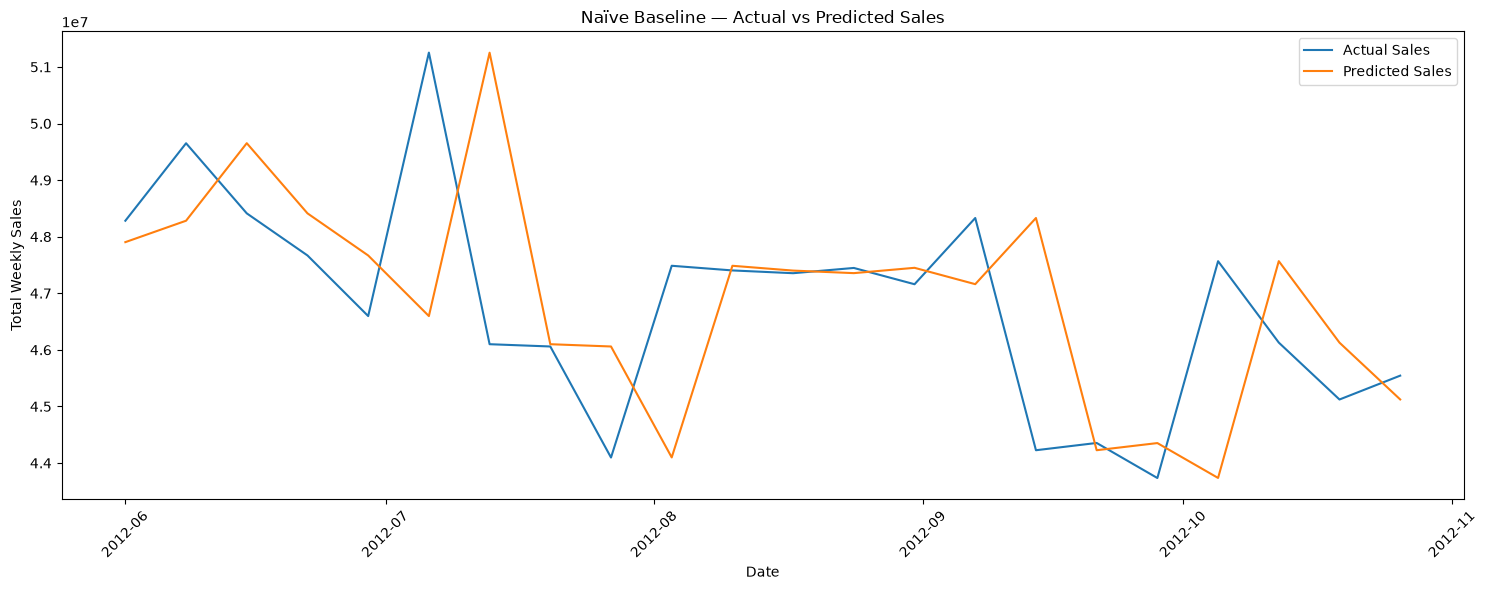

In [23]:
#Plot Actual vs Predicted

plt.figure(figsize=(15, 6))

plt.plot(
    daily_baseline["Date"],
    daily_baseline["Actual_Sales"],
    label="Actual Sales"
)

plt.plot(
    daily_baseline["Date"],
    daily_baseline["Predicted_Sales"],
    label="Predicted Sales"
)

plt.title("Naïve Baseline — Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Residual Analysis

In [24]:
#Residual = Actual − Predicted

baseline_test["Residual"] = (
    baseline_test["Weekly_Sales"]
    - baseline_test["Predicted_Sales"]
)

In [25]:
#Inspect Residuals

baseline_test[
    [
        "Date",
        "Store",
        "Dept",
        "Weekly_Sales",
        "Predicted_Sales",
        "Residual"
    ]
].head(20)

,Date,Store,Dept,Weekly_Sales,Predicted_Sales,Residual
121,2012-06-01,1,1,16065.49,16963.55,-898.06
122,2012-06-08,1,1,17666.00,16065.49,1600.51
123,2012-06-15,1,1,17558.82,17666.00,-107.18
124,2012-06-22,1,1,16633.41,17558.82,-925.41
125,2012-06-29,1,1,15722.82,16633.41,-910.59
126,2012-07-06,1,1,17823.37,15722.82,2100.55
127,2012-07-13,1,1,16566.18,17823.37,-1257.19
128,2012-07-20,1,1,16348.06,16566.18,-218.12
129,2012-07-27,1,1,15731.18,16348.06,-616.88
130,2012-08-03,1,1,16628.31,15731.18,897.13


In [26]:
#Residual Statistics

baseline_test["Residual"].describe()

count    65081.000000
mean       -36.307014
std       3476.003500
min     -91952.750000
25%       -588.420000
50%         -2.940000
75%        533.690000
max      85585.610000
Name: Residual, dtype: float64

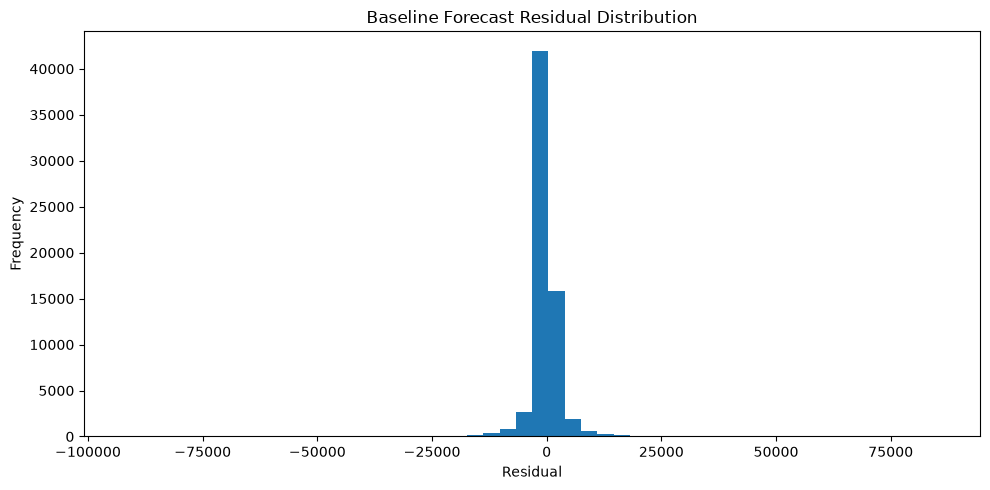

In [27]:
#Residual Distribution

plt.figure(figsize=(10, 5))

plt.hist(
    baseline_test["Residual"],
    bins=50
)

plt.title("Baseline Forecast Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

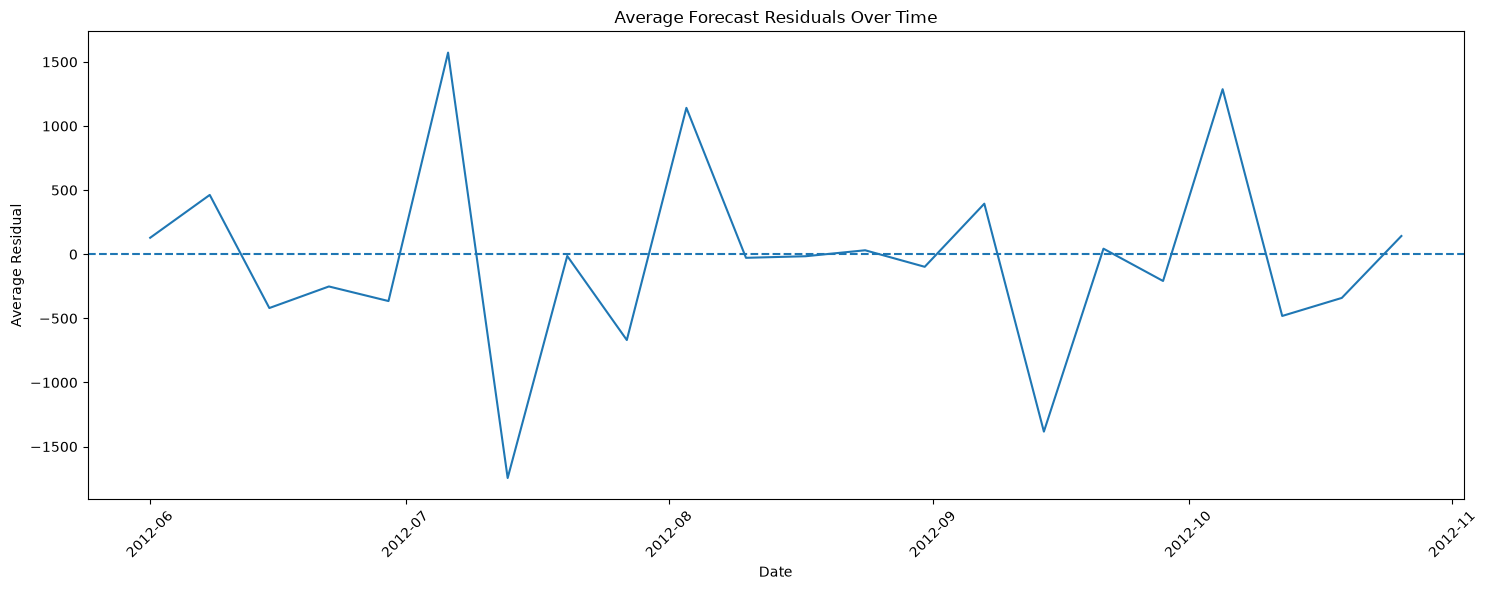

In [28]:
#Residuals Over Time

residual_over_time = (
    baseline_test
    .groupby("Date")["Residual"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(15, 6))

plt.plot(
    residual_over_time["Date"],
    residual_over_time["Residual"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Average Forecast Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Average Residual")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Largest Forecast Errors

In [29]:
#Largest Underpredictions

baseline_test.nlargest(
    10,
    "Residual"
)[
    [
        "Date",
        "Store",
        "Dept",
        "Weekly_Sales",
        "Predicted_Sales",
        "Residual"
    ]
]

,Date,Store,Dept,Weekly_Sales,Predicted_Sales,Residual
149306,2012-10-19,16,9,111246.19,25660.58,85585.61
276186,2012-09-07,28,92,153061.49,79561.10,73500.39
276177,2012-07-06,28,92,147221.14,77039.96,70181.18
276190,2012-10-05,28,92,142220.30,80209.05,62011.25
276320,2012-07-06,28,93,92790.07,35886.82,56903.25
332310,2012-06-01,35,11,76321.27,19514.00,56807.27
137341,2012-09-07,14,92,190579.72,138589.09,51990.63
276181,2012-08-03,28,92,132842.61,81536.31,51306.30
166629,2012-09-07,17,92,105950.68,55074.27,50876.41
276329,2012-09-07,28,93,84960.92,36508.03,48452.89


In [30]:
#Largest Overpredictions

baseline_test.nsmallest(
    10,
    "Residual"
)[
    [
        "Date",
        "Store",
        "Dept",
        "Weekly_Sales",
        "Predicted_Sales",
        "Residual"
    ]
]

,Date,Store,Dept,Weekly_Sales,Predicted_Sales,Residual
149307,2012-10-26,16,9,19293.44,111246.19,-91952.75
118028,2012-09-14,13,3,37384.66,114230.60,-76845.94
276187,2012-09-14,28,92,87565.69,153061.49,-65495.80
332311,2012-06-08,35,11,20810.22,76321.27,-55511.05
108322,2012-09-07,12,3,26329.11,81613.96,-55284.85
276178,2012-07-13,28,92,92070.70,147221.14,-55150.44
29937,2012-08-24,4,3,52365.07,103193.89,-50828.82
218374,2012-06-29,23,11,31719.37,78530.70,-46811.33
361498,2012-09-07,39,3,27998.09,74657.40,-46659.31
137329,2012-06-15,14,92,160550.27,206575.90,-46025.63


In [31]:
#Baseline Model by Store

store_baseline = (
    baseline_test
    .groupby("Store")
    .apply(
        lambda x: pd.Series({
            "MAE": mean_absolute_error(
                x["Weekly_Sales"],
                x["Predicted_Sales"]
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    x["Weekly_Sales"],
                    x["Predicted_Sales"]
                )
            )
        }),
        include_groups=False
    )
    .reset_index()
)

store_baseline.head()

,Store,MAE,RMSE
0,1,2207.710972,4393.686960
1,2,2255.943898,4221.691523
2,3,769.609263,1729.234288
3,4,2237.975448,4040.378645
4,5,575.923431,1288.319389


In [32]:
#Best Performing Stores

store_baseline.sort_values(
    "MAE"
).head(10)

,Store,MAE,RMSE
43,44,449.823121,1581.999070
29,30,454.111149,1246.236503
36,37,534.851268,1660.589774
4,5,575.923431,1288.319389
35,36,577.451244,1250.216638
32,33,586.020379,1369.748038
37,38,758.579907,2470.765200
2,3,769.609263,1729.234288
6,7,980.027958,2223.212007
8,9,1005.628079,2140.960101


In [33]:
#Worst Performing Stores

store_baseline.sort_values(
    "MAE",
    ascending=False
).head(10)

,Store,MAE,RMSE
13,14,2860.831141,5889.145285
19,20,2795.330936,5321.579679
27,28,2755.037030,7213.615378
1,2,2255.943898,4221.691523
26,27,2251.964503,4327.905669
3,4,2237.975448,4040.378645
12,13,2222.464366,4493.251470
0,1,2207.710972,4393.686960
22,23,2148.744321,4042.115704
23,24,2148.659352,4231.250112


#### Baseline Performance Summary

The Naïve Baseline model predicts each Store–Department week's sales using the previous week's sales.

The model was evaluated using:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)

MAE and RMSE are treated as the primary evaluation metrics because the Walmart dataset contains zero/negative sales values that can make MAPE unstable.

The baseline results will serve as the benchmark for comparing more advanced forecasting models such as Prophet, XGBoost, and LightGBM.

In [34]:
#Display the Results

baseline_results

,Model,MAE,RMSE,MAPE
0,Naive Baseline,1540.862076,3476.166405,5.397247e+15


In [36]:
#Save Baseline
baseline_results.to_csv(
    "../reports/figures/baseline_results.csv",
    index=False
)

#### Key Observations

- The Naïve Baseline provides a simple benchmark for Walmart weekly sales forecasting.
- Previous-week sales provide useful predictive information because retail demand often shows short-term persistence.
- The baseline cannot explicitly capture complex seasonal patterns, holiday effects, store characteristics, department behavior, or external economic factors.
- Forecast errors are expected to be larger during periods of sudden demand changes and seasonal peaks.
- Store-level evaluation shows that forecasting performance varies across Walmart locations.
- MAE and RMSE provide the most reliable comparison metrics for this project, while MAPE should be interpreted cautiously.
- More advanced forecasting models should outperform the Naïve Baseline to justify their additional complexity.

#### Executive Summary

The Naïve Baseline model establishes the initial forecasting benchmark for the Walmart Sales Forecasting project.

The model uses the previous week's sales for the same Store–Department combination to predict the current week's sales. This approach is intentionally simple and provides an important reference point for evaluating more sophisticated forecasting techniques.

The evaluation demonstrates that historical sales contain meaningful information about future demand. However, the baseline model has limited ability to respond to seasonal changes, holidays, long-term trends, store characteristics, department behavior, and external economic conditions.

The baseline MAE and RMSE will therefore be used as benchmark values throughout the remaining modeling stages.

The next stage will introduce a more advanced time-series forecasting approach using Prophet, followed by machine learning models such as XGBoost and LightGBM.

The ultimate objective is to identify a model that provides improved forecasting accuracy while remaining practical for business use in inventory planning and staffing decisions.